In [1]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import numpy as np
import yaml
import helpers_eda_inicial
import unicodedata
from helpers_finalizacion_carrera import get_porcentaje_aprobadas, get_anio_mayor_proporcion, plot_porcentaje_aprobadas_por_anio, get_egresados_fisica, plot_egresados_fisica_por_anio

/Users/solcalloni/Documents/github/modelos-para-prediccion-de-abandono/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/solcalloni/Documents/github/modelos-para-prediccion-de-abandono/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Tomamos los documentos base

In [2]:
personas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv')
personas['dni'] = personas['dni'].astype(str)
actas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv', encoding='latin-1', dtype={'dni': str})

In [3]:
#cambio los registros de la columna 'materia' para que esten en mayuscula, sin espacios al principio ni al final, y sin tildes.
actas['materia'] = actas['materia'].str.upper().str.strip()
actas['materia'] = actas['materia'].apply(lambda x: unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('ASCII'))

In [4]:
materias_fisica = (
    actas[actas['carrera'] == 'Licenciatura en Ciencias Físicas']['materia']
    .value_counts()
    .rename_axis('materia')
    .reset_index(name='cantidad')
)

materias_fisica

,materia,cantidad
0,MATEMATICA 1,6271
1,MATEMATICA 2,5704
2,FISICA 2,4409
3,MATEMATICA 3,4389
4,LABORATORIO 1,4068
...,...,...
88,TEORIA DE CAMPOS,1
89,TERMODINAMICA ESTADISTICA,1
90,TEMAS AVANZADOS DE TEORIA DE CAMPOS,1
91,ALGORITMOS Y ESTRUCTURAS DE DATOS I,1


## Física

Abrimos el yaml con las materias de física.

In [5]:
with open('../../constants/materias_fisica.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias = [m for plan in config['planes'] for m in plan['materias']]

In [6]:
materias = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias]
materias

['FISICA 1',
 'FISICA 2',
 'FISICA 3',
 'FISICA 4',
 'LABORATORIO 1',
 'LABORATORIO 2',
 'LABORATORIO 3',
 'LABORATORIO 4',
 'LABORATORIO 5',
 'LABORATORIO 6',
 'LABORATORIO 7',
 'MECANICA CLASICA',
 'FISICA TEORICA 1',
 'FISICA TEORICA 2',
 'FISICA TEORICA 3',
 'ESTRUCTURA DE LA MATERIA 1',
 'ESTRUCTURA DE LA MATERIA 2',
 'ESTRUCTURA DE LA MATERIA 3',
 'ESTRUCTURA DE LA MATERIA 4',
 'MATEMATICA 1',
 'MATEMATICA 2',
 'MATEMATICA 3',
 'MATEMATICA 4',
 'CALCULO NUMERICO',
 'TESIS DE LICENCIATURA']

In [7]:
materias_fisica[materias_fisica['materia'].isin(materias)]

,materia,cantidad
0,MATEMATICA 1,6271
1,MATEMATICA 2,5704
2,FISICA 2,4409
3,MATEMATICA 3,4389
4,LABORATORIO 1,4068
5,FISICA 1,3955
6,FISICA 3,3652
7,MATEMATICA 4,3381
8,LABORATORIO 2,3010
9,CALCULO NUMERICO,2978


Justo vemos que todas las materias aparecen en el listado de actas.

In [8]:
fisicos = personas[personas['carrera_principal'] == 'Licenciatura en Ciencias Físicas'][['dni', 'año_inscripcion_facultad']]

In [9]:
fisicos.shape

(2796, 2)

In [10]:
actas_de_fisicos = actas[actas['dni'].isin(fisicos['dni'])]

In [11]:
actas_de_fisicos.shape

(79680, 7)

In [12]:
actas_de_fisicos['dni'].nunique()

2796

In [13]:
actas_de_fisicos = actas_de_fisicos[(actas_de_fisicos['materia'].isin(materias)) & (actas_de_fisicos['tipo_acta'] == 'Acta de Examen') & (actas_de_fisicos['resultado'] == 'Aprobado')]

In [14]:
actas_de_fisicos.shape

(28526, 7)

Quiero ver la cantidad de dni con 1 materia aprobada, 2 materias aprobadas, 3 materias aprobadas... hasta el máximo que es 25.

In [15]:
# Quiero ver la cantidad de dni con 1 materia aprobada, 2 materias aprobadas, 3 materias aprobadas... hasta el máximo que es 25.
# Primero nos quedamos con el registro más reciente por cada (dni, materia)
# La fecha ya está en formato YYYY-MM-DD, solo necesitamos convertirla a datetime
actas_de_fisicos['fecha'] = pd.to_datetime(actas_de_fisicos['fecha'], format='%Y-%m-%d', errors='coerce')
actas_de_fisicos_unicos = actas_de_fisicos.sort_values('fecha').drop_duplicates(subset=['dni', 'materia', 'carrera'], keep='last')

# Ahora contamos las materias aprobadas por cada estudiante
actas_de_fisicos_unicos['cantidad_materias_aprobadas'] = actas_de_fisicos_unicos.groupby('dni')['materia'].transform('count')
cantidad_materias_aprobadas = actas_de_fisicos_unicos.groupby('dni')['cantidad_materias_aprobadas'].first().value_counts().reset_index()
cantidad_materias_aprobadas.columns = ['cantidad_materias_aprobadas', 'cantidad_estudiantes']
cantidad_materias_aprobadas.sort_values('cantidad_materias_aprobadas', inplace=True)
cantidad_materias_aprobadas

,cantidad_materias_aprobadas,cantidad_estudiantes
1,1,372
2,2,184
5,3,96
4,4,96
3,5,99
9,6,87
11,7,68
6,8,94
8,9,89
10,10,86


Como solo me interesa almacenar dni, materia, carrera y fecha, nos quedarnos con la más reciente en caso de que haya rendido y aprobado la materia más de una vez. Es así, como nos queda que exactamente 473 personas tienen todos los registros de las materias de física.

In [16]:
actas[actas['materia'] == 'TESIS DE LICENCIATURA']['fecha'].min()

'2012-05-11'

In [17]:
actas[actas['materia'] == 'TESIS DE LICENCIATURA']['carrera'].value_counts()

carrera
Licenciatura en Ciencias Físicas              595
Licenciatura en Ciencias de la Computación    402
Licenciatura en Ciencias Biológicas           272
Licenciatura en Ciencias Matemáticas          228
Licenciatura en Ciencias de la Atmósfera      119
Licenciatura en Paleontología                  71
Licenciatura en Ciencias de Datos              43
Licenciatura en Oceanografía                   24
Licenciatura en Ciencias Oceanográficas         5
Materias de Otras Carreras                      5
Name: count, dtype: int64

Vemos que la materia 'TESIS DE LICENCIATURA' no aparece para las carreras:

* Química
* Ciencias de la Atmósfera
* Ciencias Geológicas
* Paleontología
* Ciencia y Tecnología de Alimentos
* Profesorados

Además, para el resto de las carreras, se comenzó a registrar el '2012-05-11'

Entonces, antes de 2012, no tendríamos que "exigir" que tenga registrado "TESIS DE LICENCIATURA", incluso en aquellas carreras donde hoy en día se lleva registro.

In [18]:
actas_de_fisicos_unicos['carrera'].value_counts()

carrera
Licenciatura en Ciencias Físicas                       28346
Materias de Otras Carreras                                76
Licenciatura en Ciencias de la Atmósfera                  24
Profesorado de Enseñanza Media y Superior en Física       12
Licenciatura en Ciencias Oceanográficas                   11
Licenciatura en Oceanografía                               6
Licenciatura en Ciencias Matemáticas                       2
Licenciatura en Ciencias de Datos                          2
Name: count, dtype: int64

Incluso habiendonos quedado con los que en su mayoría se anotaron con la carrera de física, vemos que hay materias que les figura por fuera de la carrera.

In [19]:
actas_de_fisicos_unicos[actas_de_fisicos_unicos['cantidad_materias_aprobadas'] == 24]['materia'].value_counts()

materia
LABORATORIO 1                 90
MECANICA CLASICA              90
LABORATORIO 7                 90
LABORATORIO 6                 90
FISICA TEORICA 3              90
LABORATORIO 5                 90
ESTRUCTURA DE LA MATERIA 1    90
FISICA TEORICA 2              90
LABORATORIO 4                 90
FISICA 4                      90
FISICA 3                      90
MATEMATICA 4                  90
MATEMATICA 3                  90
FISICA TEORICA 1              89
LABORATORIO 2                 89
FISICA 2                      89
FISICA 1                      88
CALCULO NUMERICO              87
LABORATORIO 3                 87
ESTRUCTURA DE LA MATERIA 4    86
ESTRUCTURA DE LA MATERIA 3    86
MATEMATICA 1                  82
ESTRUCTURA DE LA MATERIA 2    73
TESIS DE LICENCIATURA         69
MATEMATICA 2                  65
Name: count, dtype: int64

Se que había 90 con 24 materias aprobadas. Vemos que esto se debe a que algunos no tienen:

* FISICA TEORICA 1
* LABORATORIO 2
* FISICA 2
* FISICA 1
* CALCULO NUMERICO
* LABORATORIO 3
* ESTRUCTURA DE LA MATERIA 4
* ESTRUCTURA DE LA MATERIA 3
* MATEMATICA 1
* ESTRUCTURA DE LA MATERIA 2
* MATEMATICA 2
* TESIS DE LICENCIATURA

Sacando la TESIS DE LICENCIATURA, que ya vimos que no siempre se registra. Es raro que solo les falte una de esas materias, porque implica que hicieron la tesis sin tener registro de la otra materia.

In [20]:
df = get_porcentaje_aprobadas(
    carreras=['Licenciatura en Ciencias Físicas'],
    anio=2014,
    path_yaml='../../constants/materias_fisica.yaml'
)

In [21]:
personas[personas['carrera_principal'] == 'Licenciatura en Ciencias Físicas']['año_inscripcion_facultad'].value_counts().sort_index()

año_inscripcion_facultad
2005     41
2006     31
2007     59
2008     52
2009     84
2010     79
2011    112
2012    139
2013    120
2014    118
2015    119
2016    120
2017    139
2018    136
2019    136
2020    142
2021    300
2022    202
2023    248
2024    237
2025    182
Name: count, dtype: int64

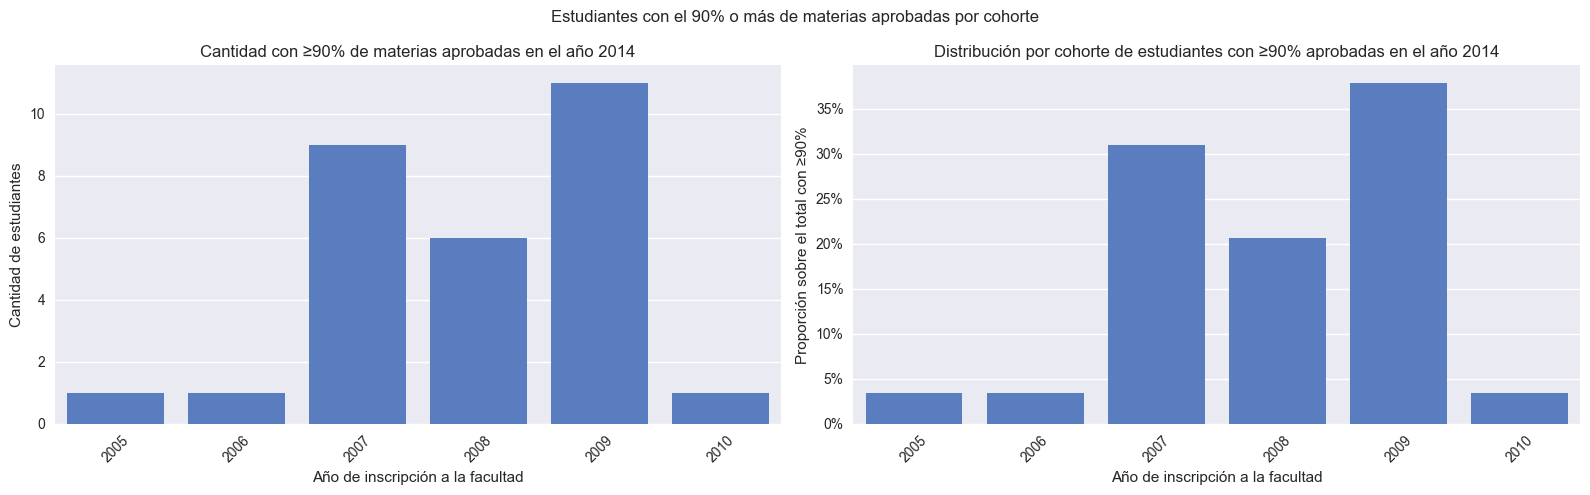

In [22]:
plot_porcentaje_aprobadas_por_anio(df, anio=2014)

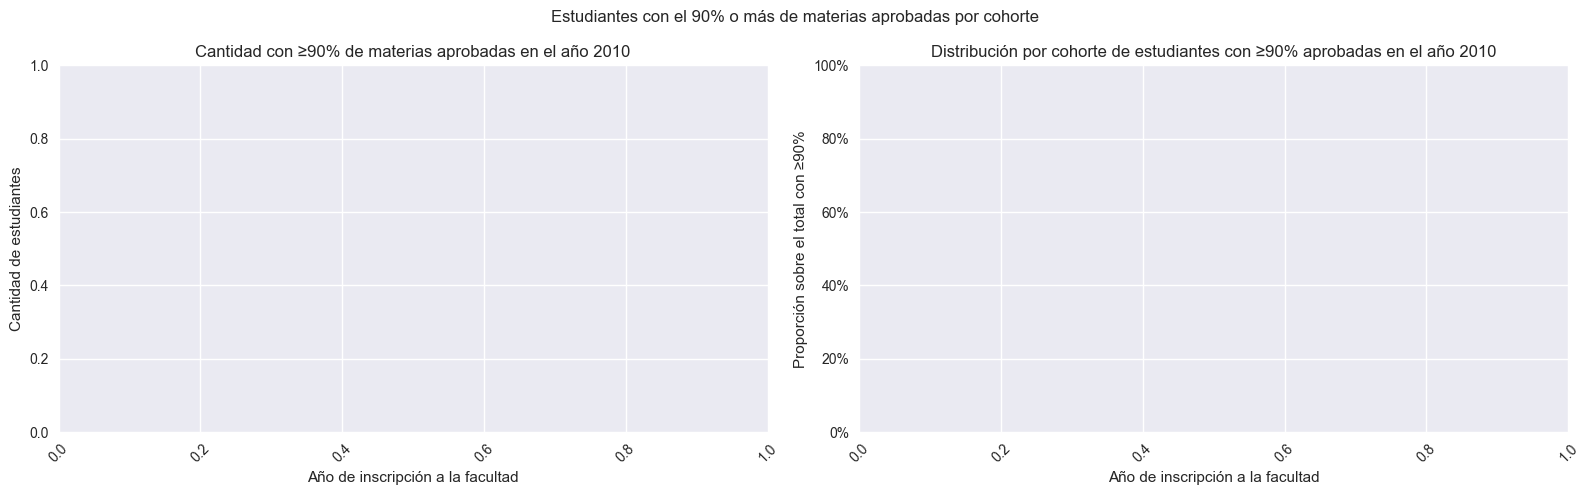

/Users/solcalloni/Documents/github/modelos-para-prediccion-de-abandono/packages/exploratory-data-analysis/FCEN_2005_2025/../helpers_finalizacion_carrera.py:485: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  return resumen["proporcion"].idxmax(), resumen["proporcion"].max()


Cohorte con mayor proporción: nan (nan%). Diferencia de nan años con el año de inscripción.


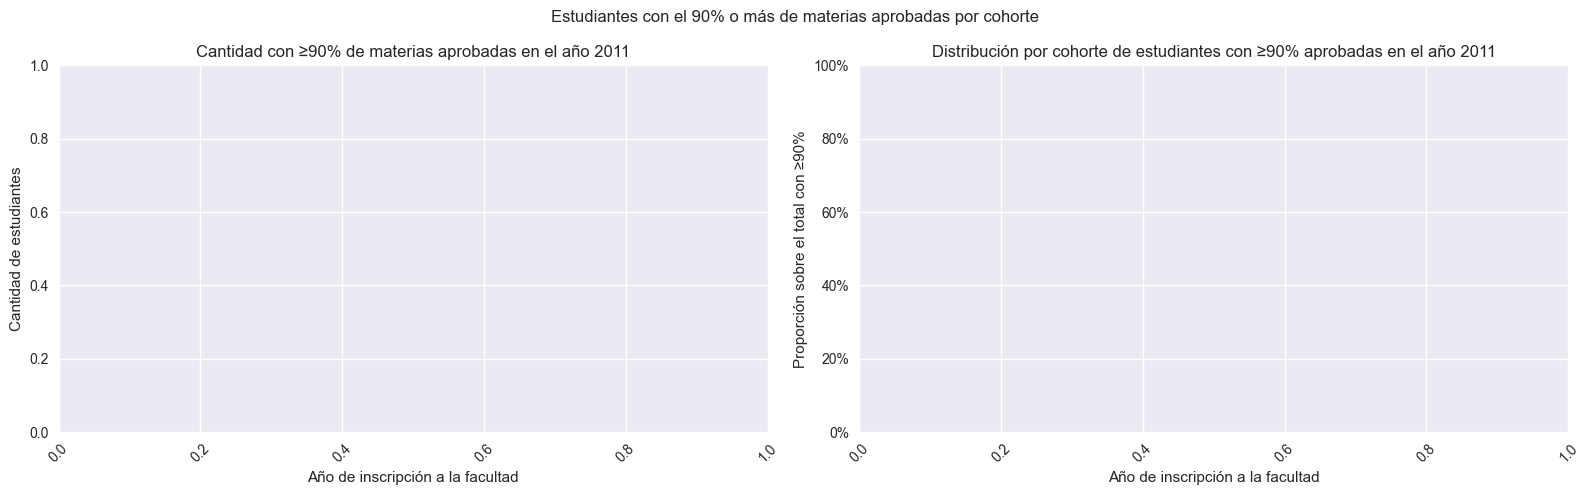

/Users/solcalloni/Documents/github/modelos-para-prediccion-de-abandono/packages/exploratory-data-analysis/FCEN_2005_2025/../helpers_finalizacion_carrera.py:485: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  return resumen["proporcion"].idxmax(), resumen["proporcion"].max()


Cohorte con mayor proporción: nan (nan%). Diferencia de nan años con el año de inscripción.


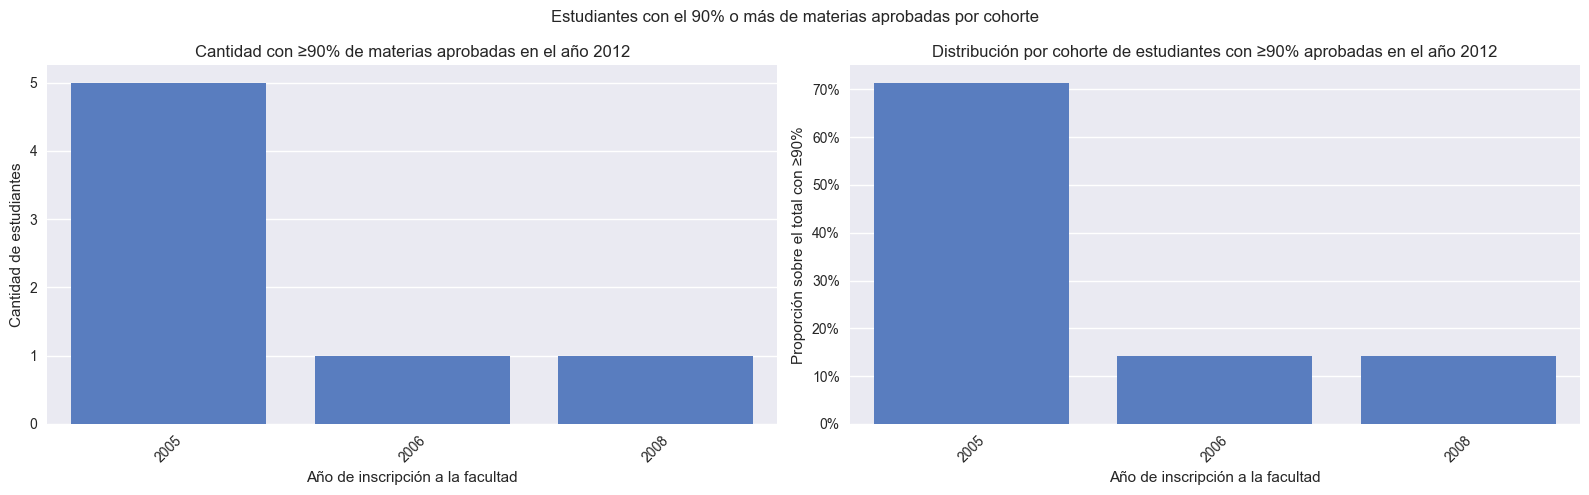

Cohorte con mayor proporción: 2005 (71.4%). Diferencia de 8 años con el año de inscripción.


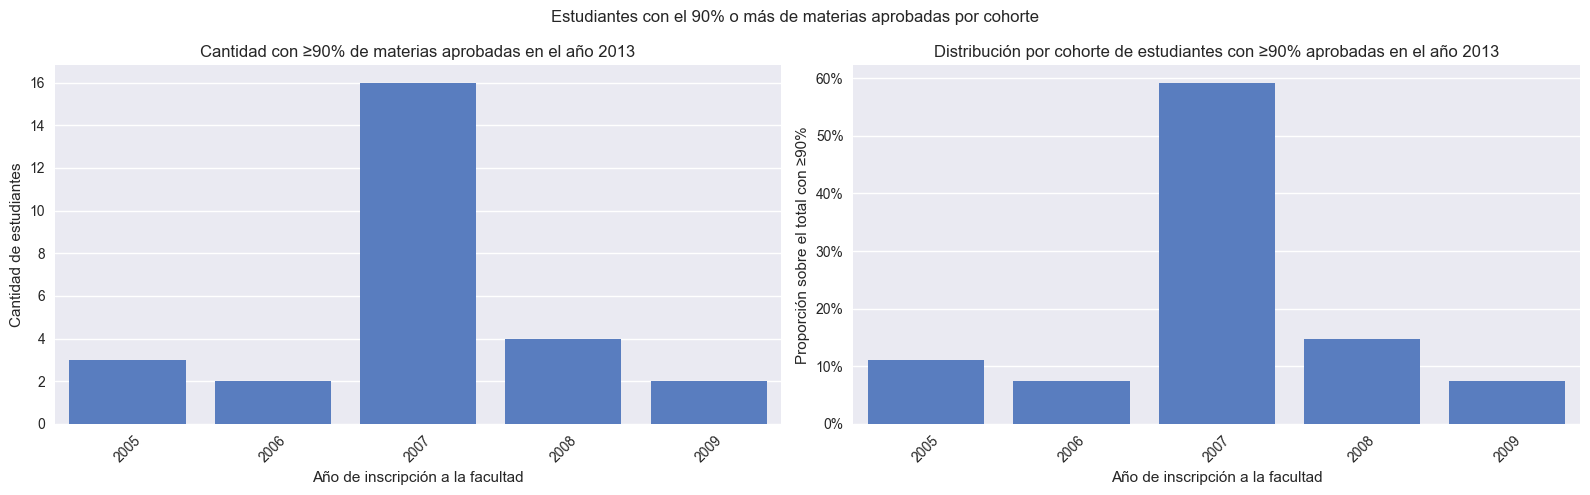

Cohorte con mayor proporción: 2007 (59.3%). Diferencia de 7 años con el año de inscripción.


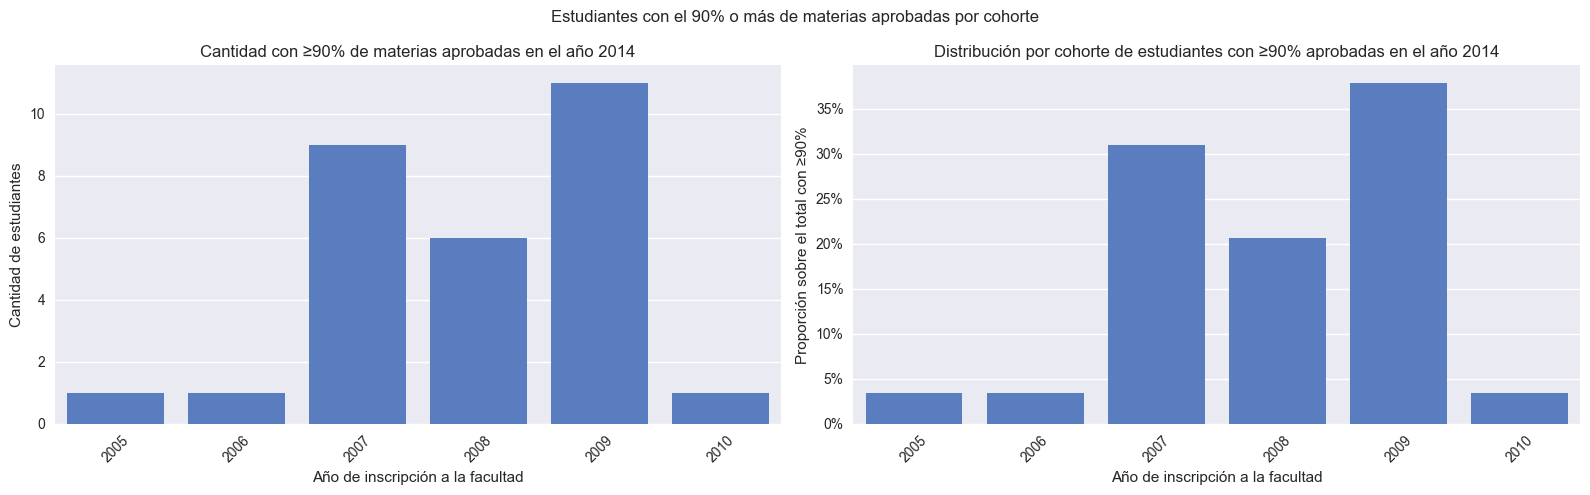

Cohorte con mayor proporción: 2009 (37.9%). Diferencia de 6 años con el año de inscripción.


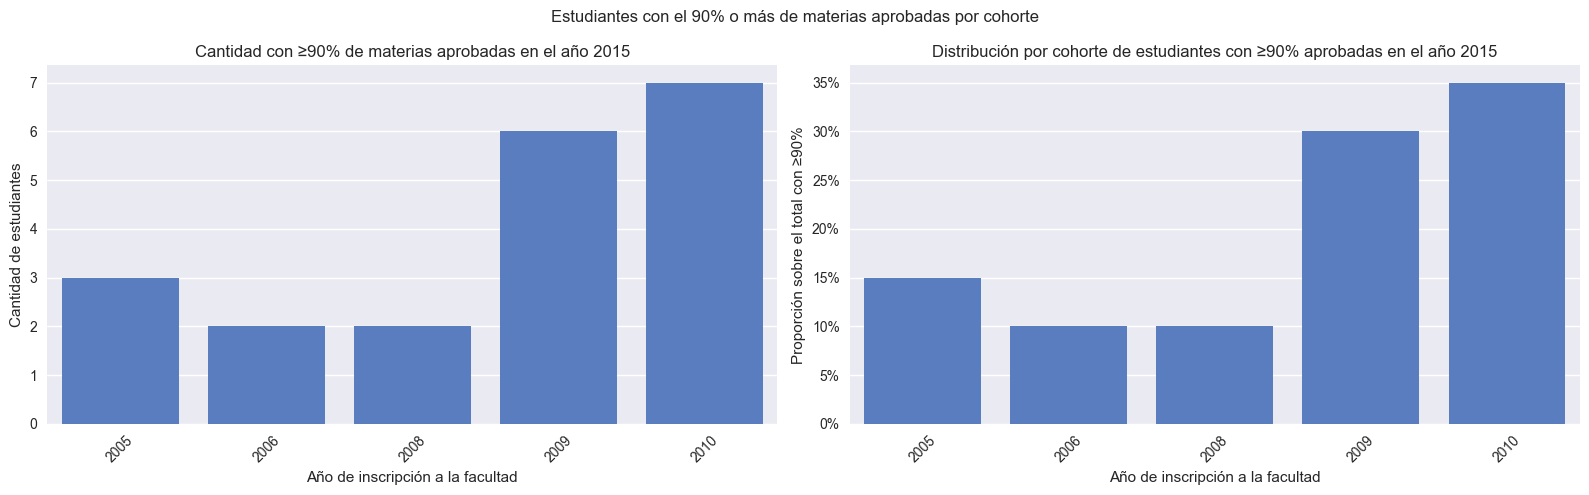

Cohorte con mayor proporción: 2010 (35.0%). Diferencia de 6 años con el año de inscripción.


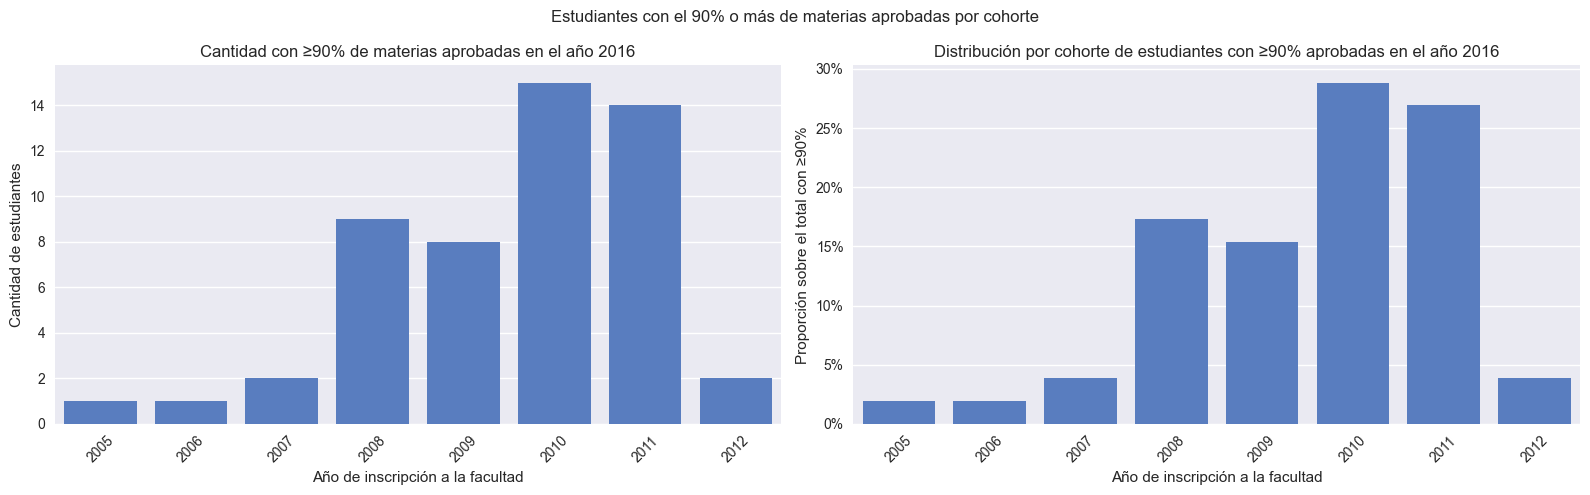

Cohorte con mayor proporción: 2010 (28.8%). Diferencia de 7 años con el año de inscripción.


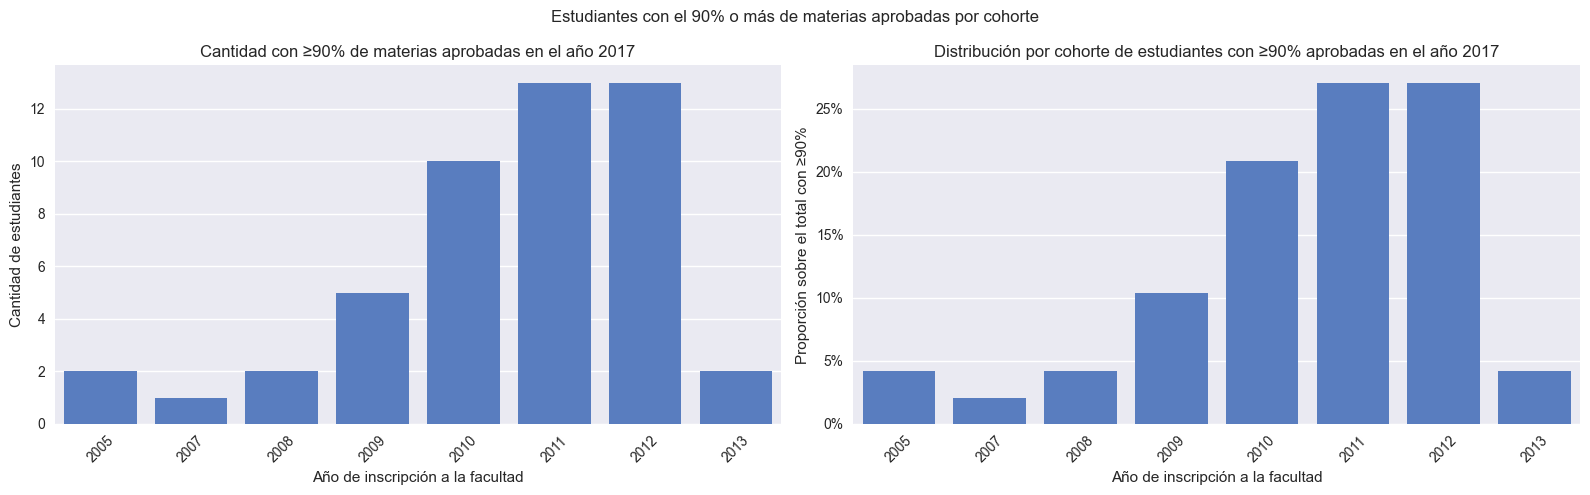

Cohorte con mayor proporción: 2011 (27.1%). Diferencia de 7 años con el año de inscripción.


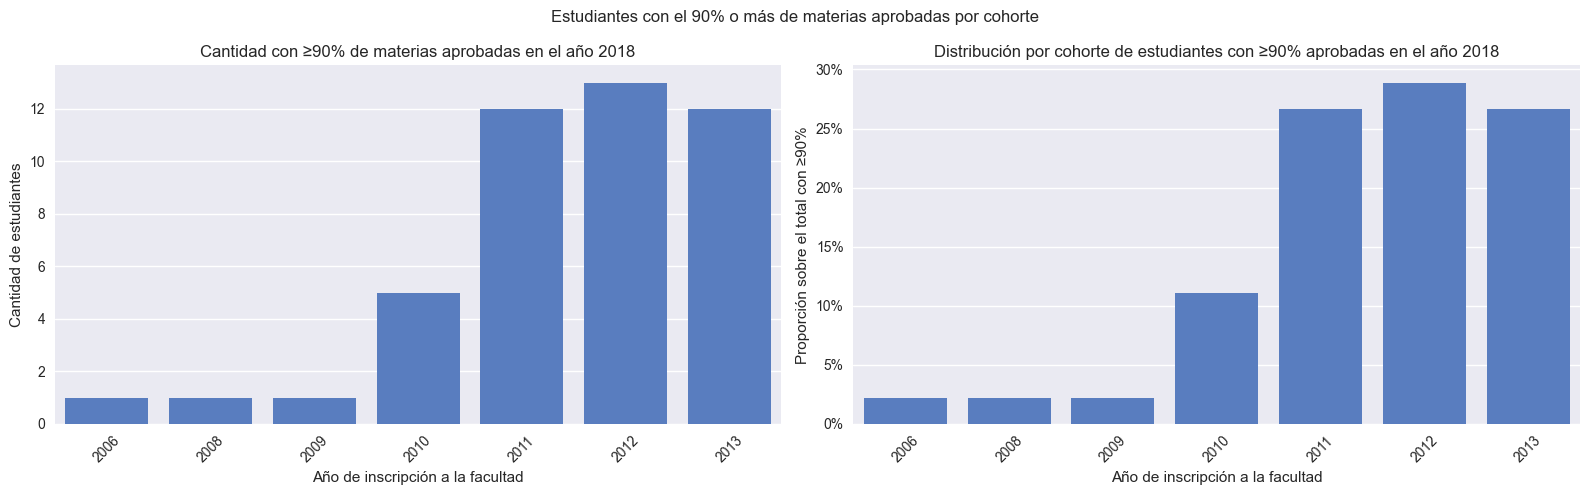

Cohorte con mayor proporción: 2012 (28.9%). Diferencia de 7 años con el año de inscripción.


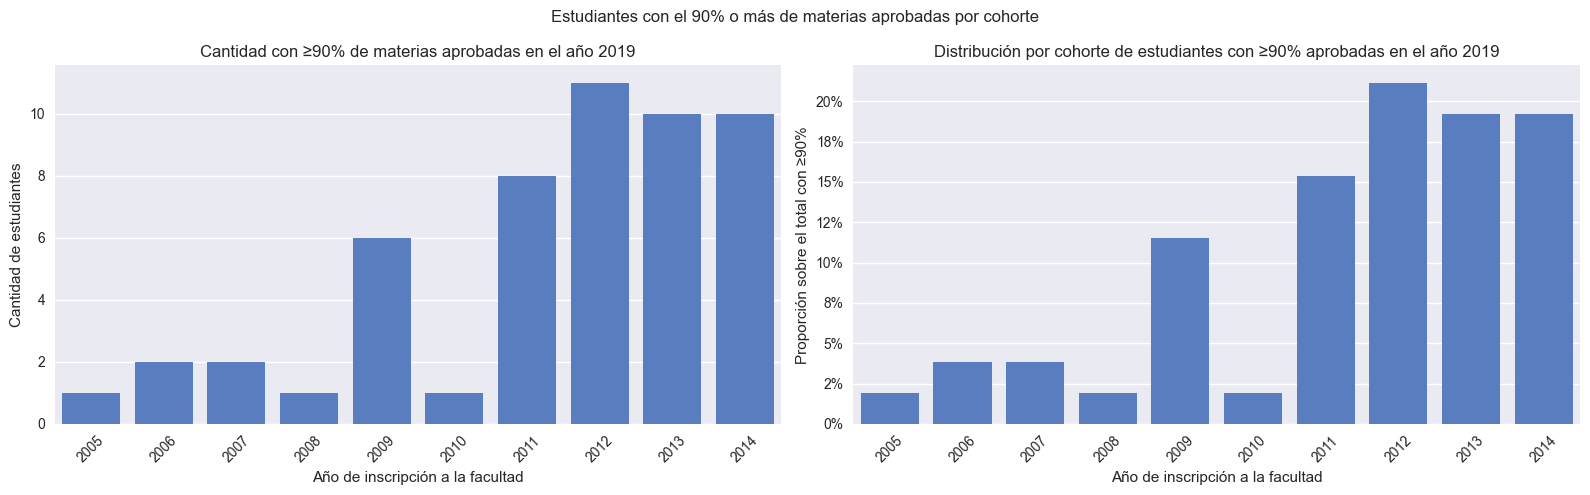

Cohorte con mayor proporción: 2012 (21.2%). Diferencia de 8 años con el año de inscripción.


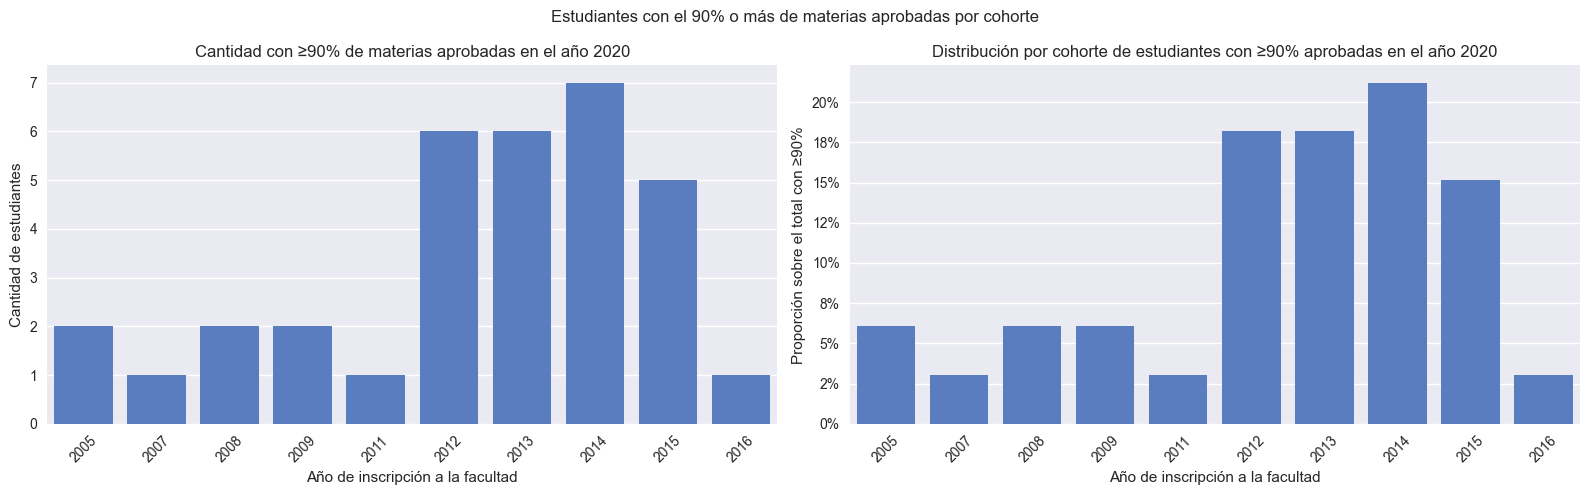

Cohorte con mayor proporción: 2014 (21.2%). Diferencia de 7 años con el año de inscripción.


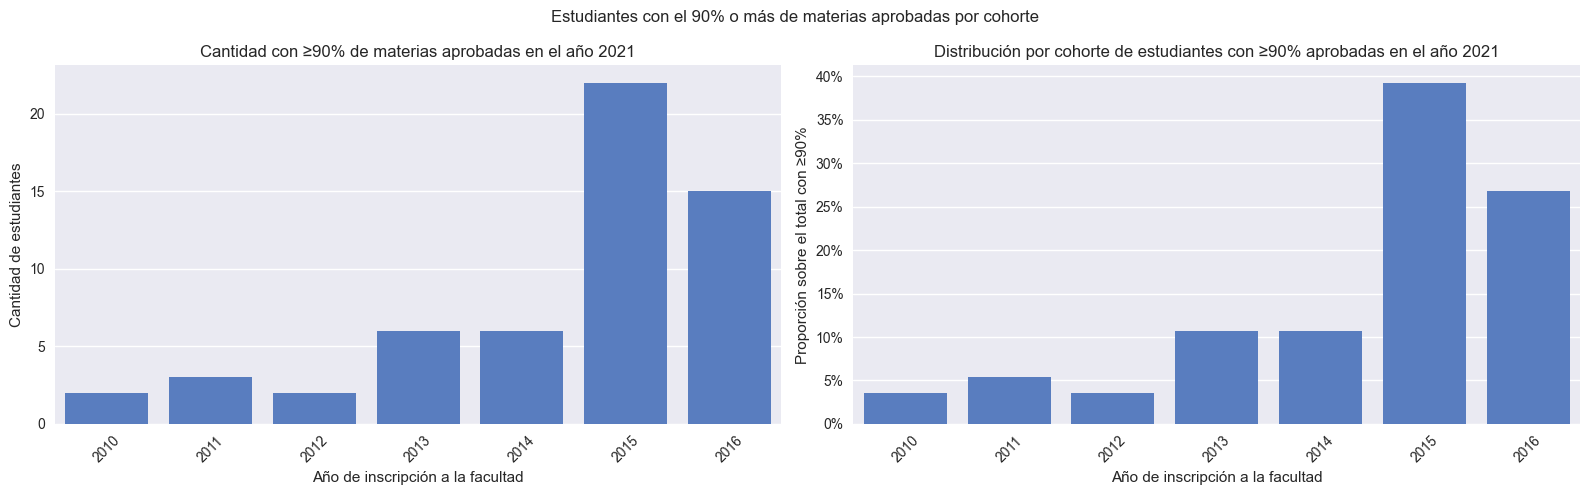

Cohorte con mayor proporción: 2015 (39.3%). Diferencia de 7 años con el año de inscripción.


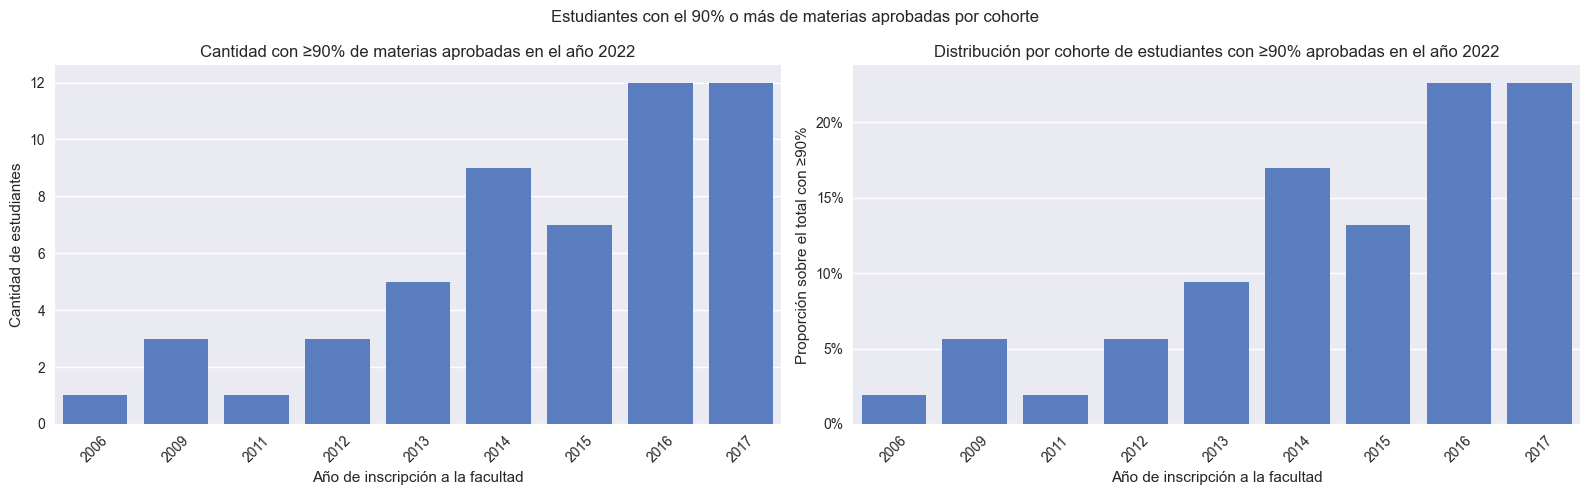

Cohorte con mayor proporción: 2016 (22.6%). Diferencia de 7 años con el año de inscripción.


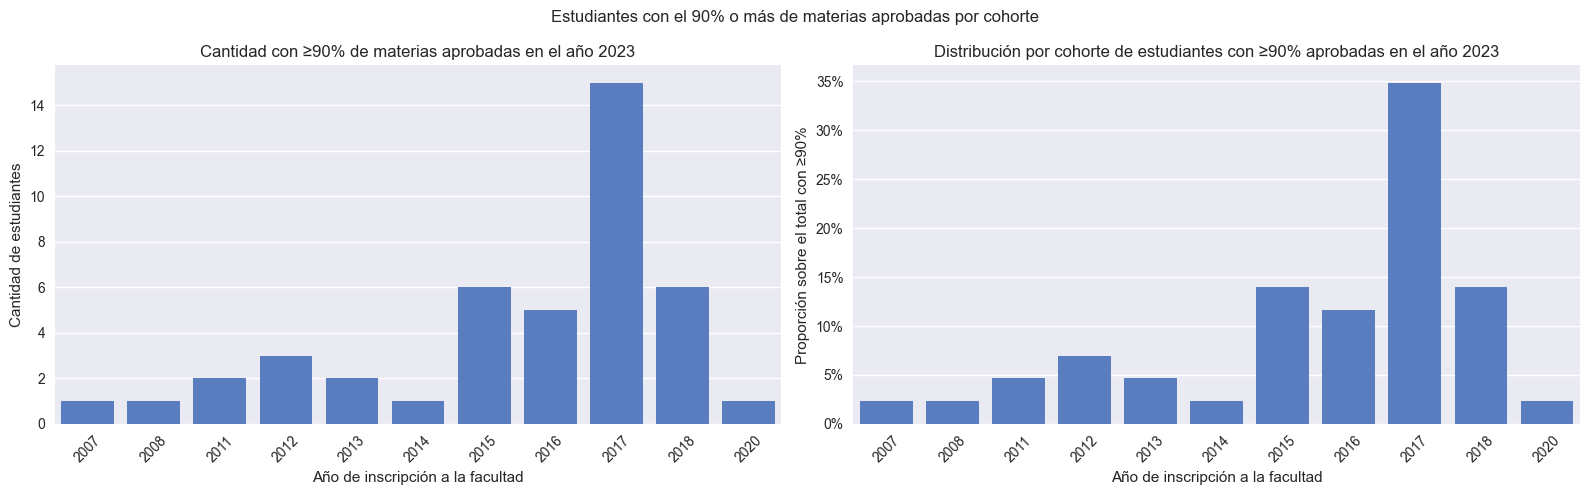

Cohorte con mayor proporción: 2017 (34.9%). Diferencia de 7 años con el año de inscripción.


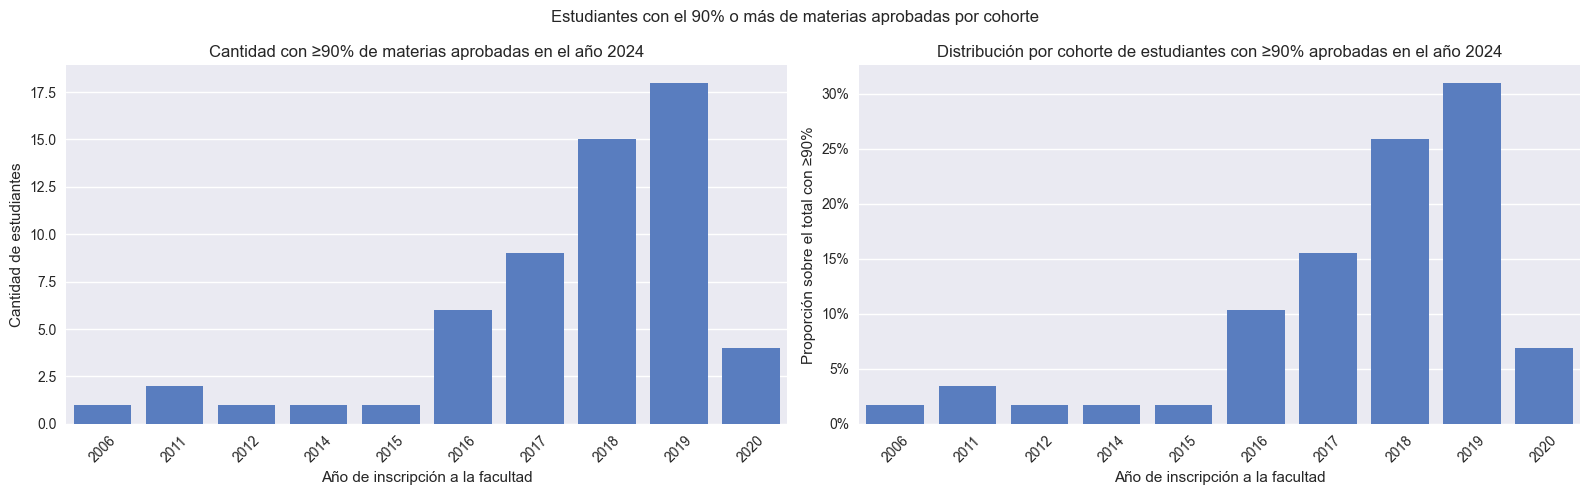

Cohorte con mayor proporción: 2019 (31.0%). Diferencia de 6 años con el año de inscripción.


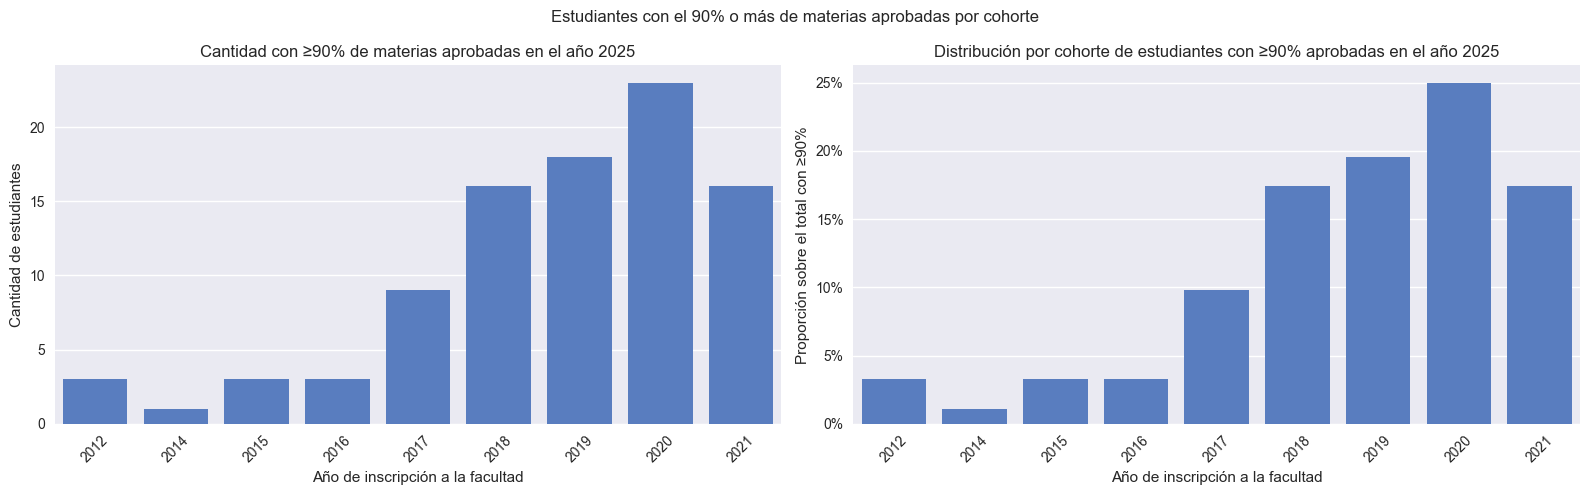

Cohorte con mayor proporción: 2020 (25.0%). Diferencia de 6 años con el año de inscripción.


In [23]:
for anio in range(2010, 2026):
    df = get_porcentaje_aprobadas(
        carreras=['Licenciatura en Ciencias Físicas'],
        anio=anio,
        path_yaml='../../constants/materias_fisica.yaml'
    )
    plot_porcentaje_aprobadas_por_anio(df, anio=anio)
    anio_principal, proporcion = get_anio_mayor_proporcion(df)
    print(f"Cohorte con mayor proporción: {anio_principal} ({proporcion:.1%}). Diferencia de {anio - anio_principal + 1} años con el año de inscripción.")

In [24]:
todas_las_cohortes = []

for anio in range(2014, 2020):
    df = get_porcentaje_aprobadas(
        carreras=['Licenciatura en Ciencias Físicas'],
        anio=anio,
        path_yaml='../../constants/materias_fisica.yaml'
    )
    df['tiempo_cursando'] = anio - df['año_inscripcion_facultad'] + 1
    df['año_egreso'] = anio
    todas_las_cohortes.append(df)

df_todos = pd.concat(todas_las_cohortes, ignore_index=True)

tabla_tiempo_cursando = (
    df_todos[df_todos["porcentaje_materias_aprobadas"] >= 0.9].groupby('tiempo_cursando')['dni']
    .count()
    .reset_index()
    .rename(columns={'dni': 'total_egreso'})
    .sort_values('tiempo_cursando')
    .reset_index(drop=True)
)

tabla_tiempo_cursando

,tiempo_cursando,total_egreso
0,5,5
1,6,67
2,7,63
3,8,52
4,9,28
5,10,9
6,11,12
7,12,2
8,13,5
9,14,2


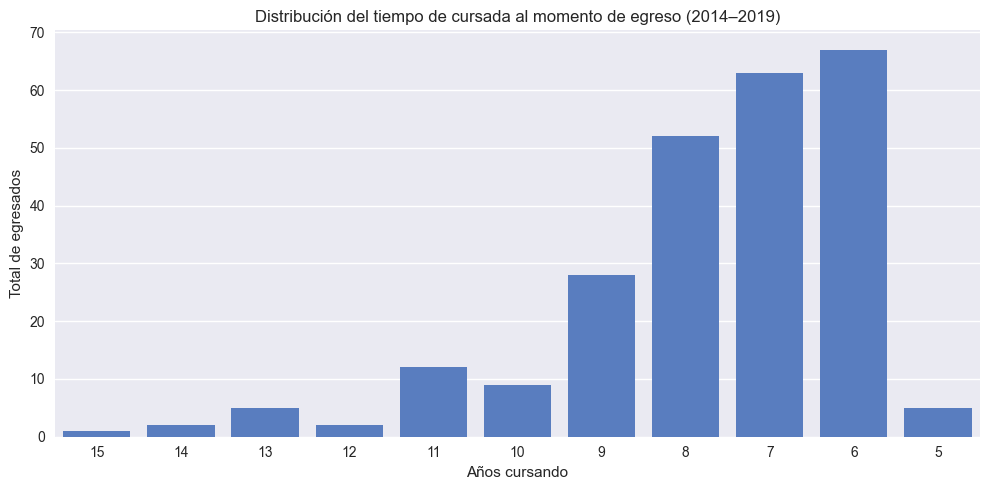

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

orden = tabla_tiempo_cursando.sort_values('tiempo_cursando', ascending=False)['tiempo_cursando'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=tabla_tiempo_cursando, x='tiempo_cursando', y='total_egreso', order=orden, ax=ax)
ax.set_xlabel('Años cursando')
ax.set_ylabel('Total de egresados')
ax.set_title('Distribución del tiempo de cursada al momento de egreso (2014–2019)')
plt.tight_layout()
plt.show()


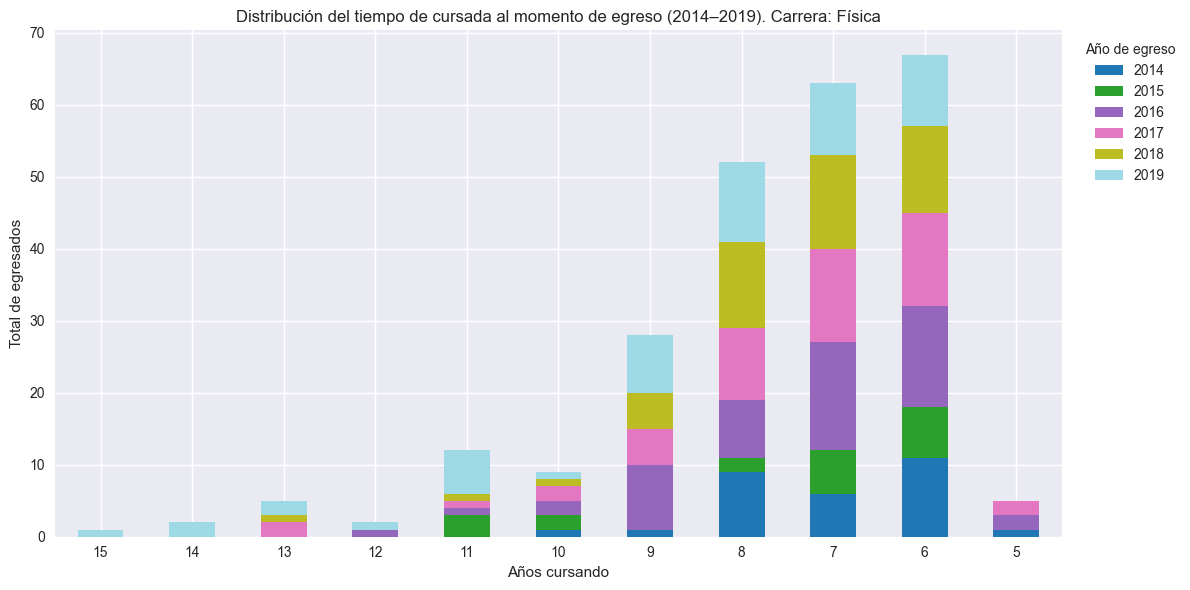

In [26]:
df_filtrado = df_todos[df_todos["porcentaje_materias_aprobadas"] >= 0.9].copy()

pivot = (
    df_filtrado.groupby(['tiempo_cursando', 'año_egreso'])['dni']
    .count()
    .unstack(fill_value=0)
)

# orden descendente en el eje x
pivot = pivot.loc[sorted(pivot.index, reverse=True)]

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_xlabel('Años cursando')
ax.set_ylabel('Total de egresados')
ax.set_title('Distribución del tiempo de cursada al momento de egreso (2014–2019). Carrera: Física')
ax.legend(title='Año de egreso', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## Segunda forma de calcular

Agregamos la consideración de materias optativas y la presencia de la tesis.

In [31]:
egresados_fisica = get_egresados_fisica(
    ['Licenciatura en Ciencias Físicas'],
    '../../constants/materias_fisica.yaml',
    '../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv',
    '../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv',
    min_materias_sin_tesis = 22
)

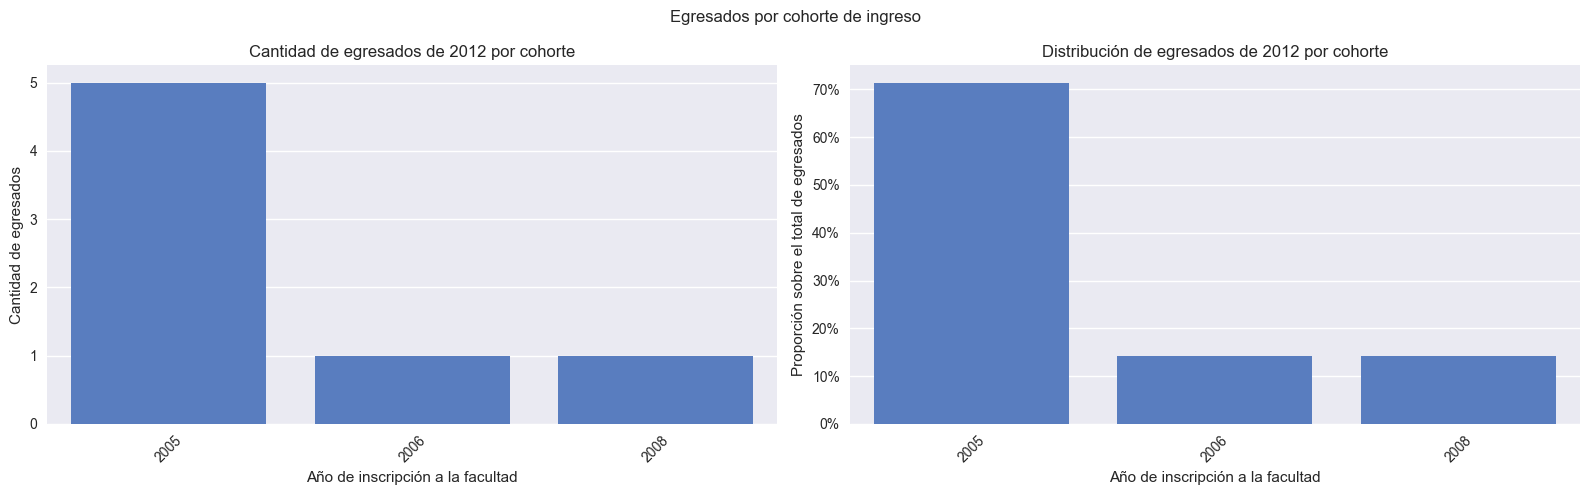

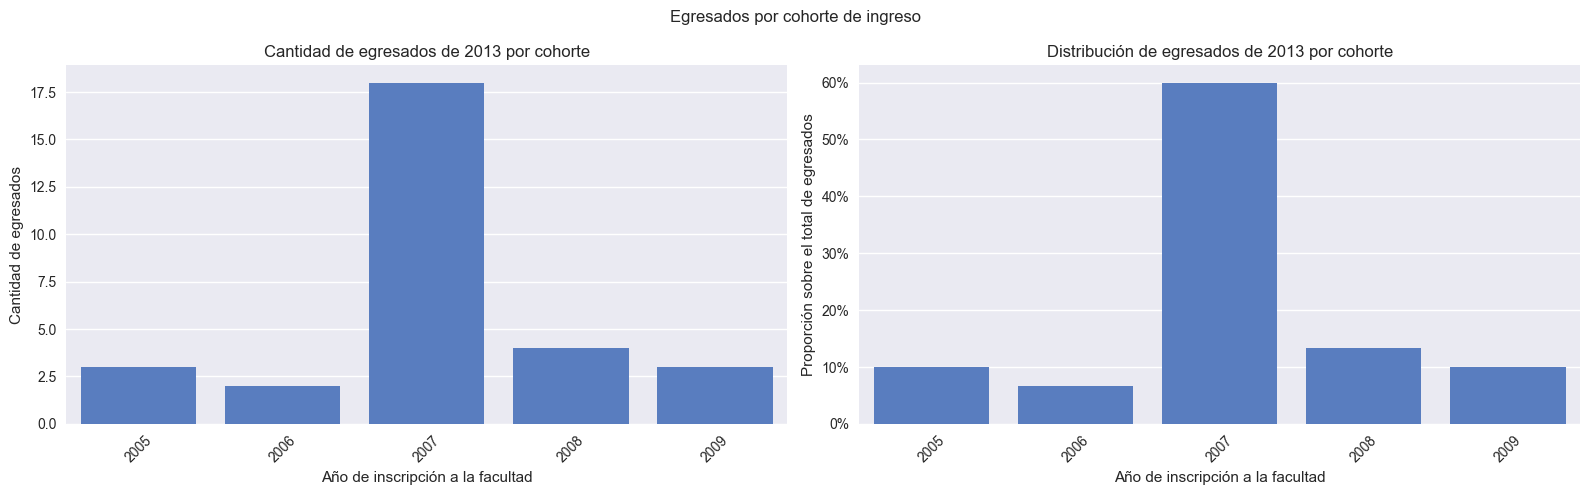

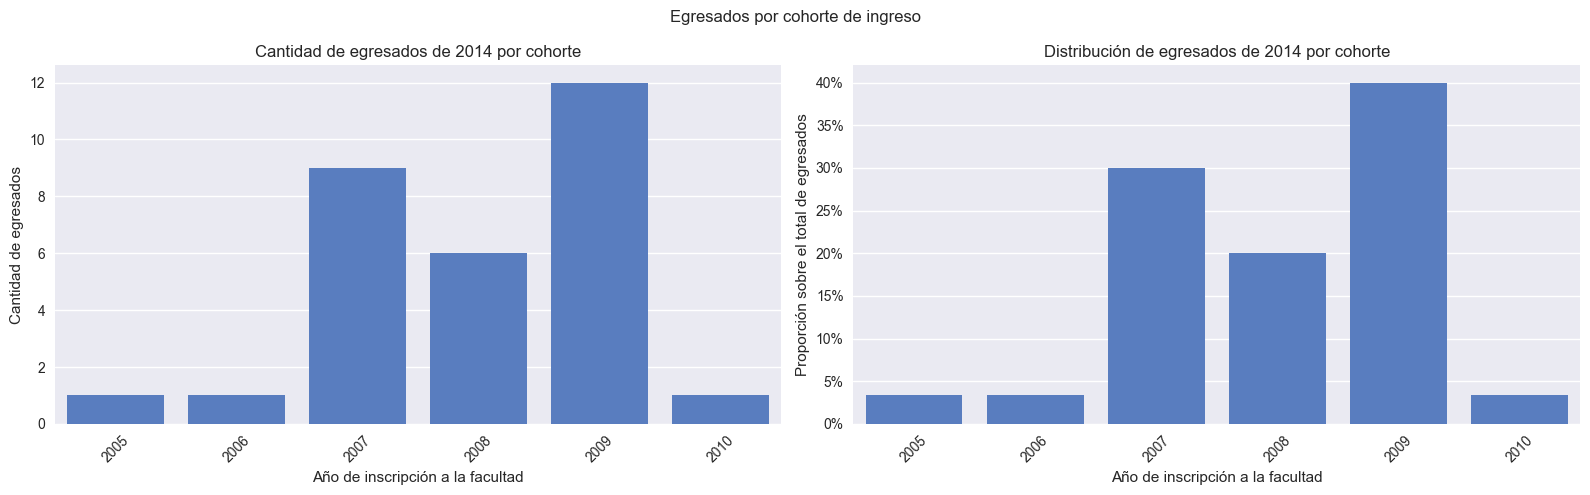

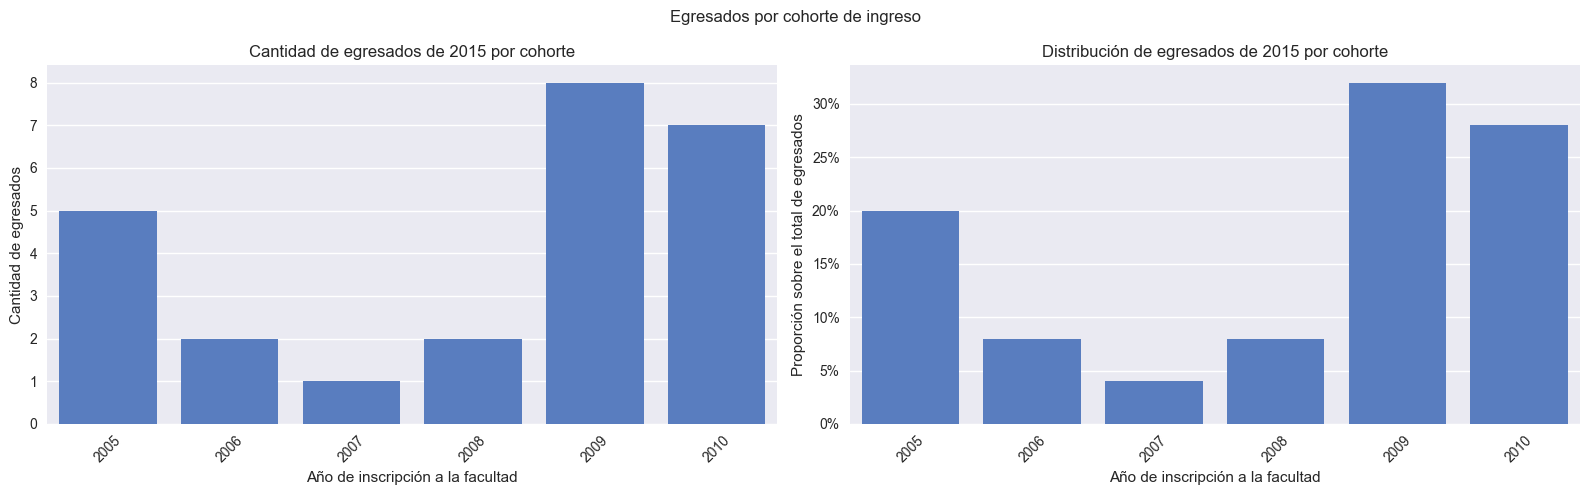

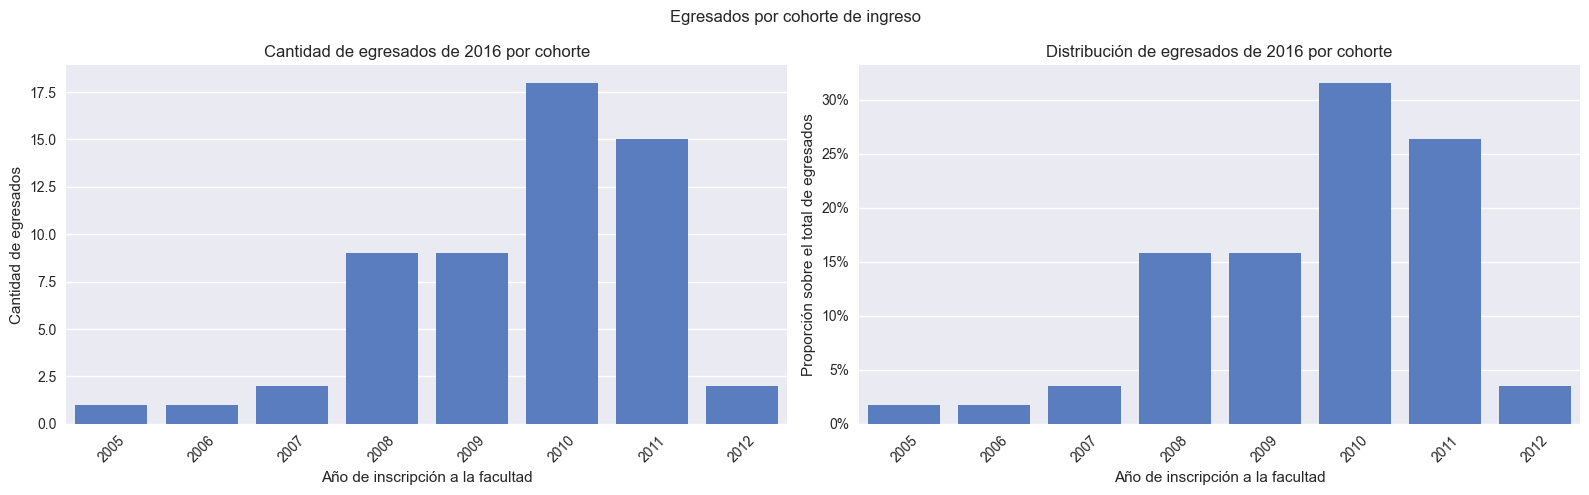

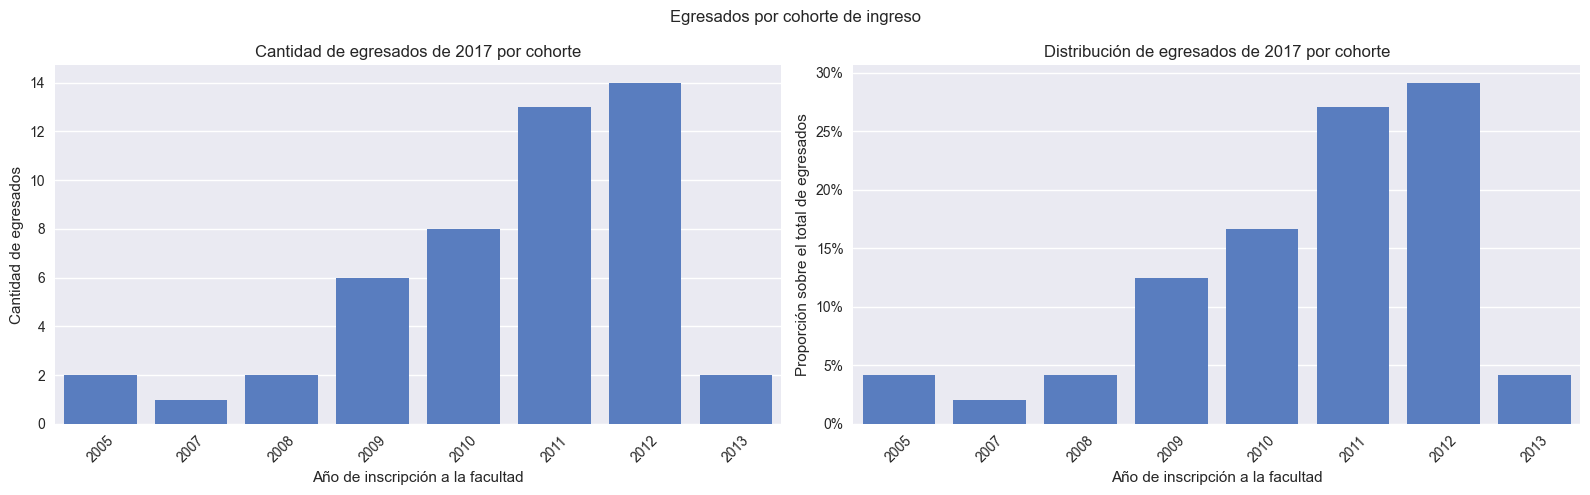

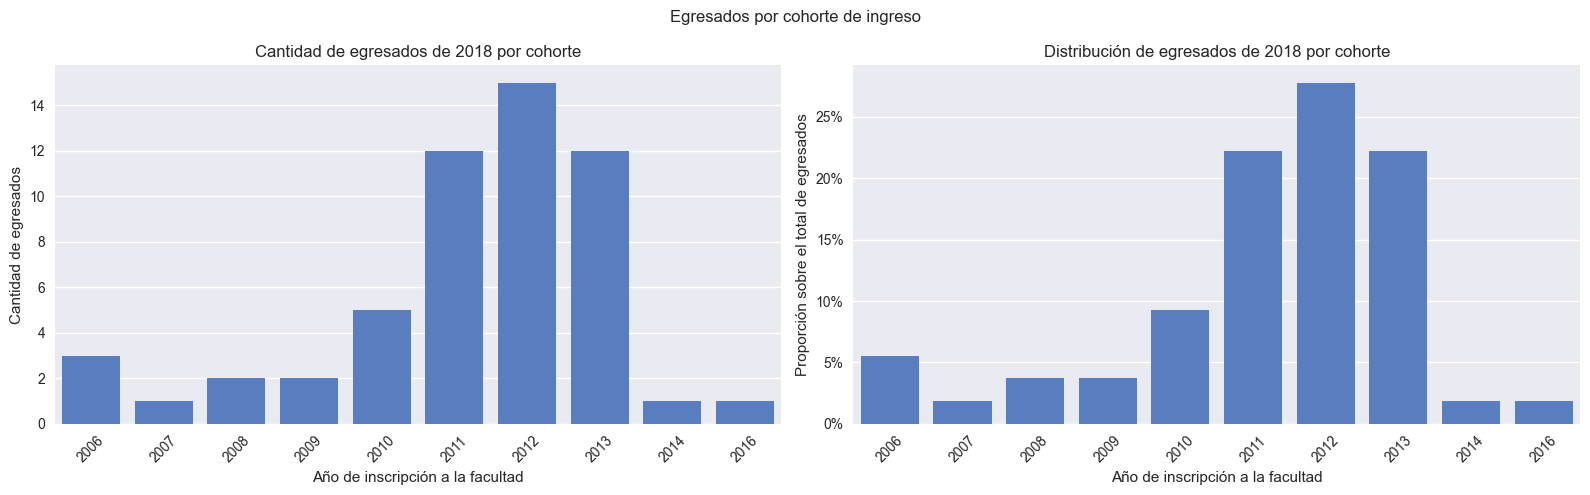

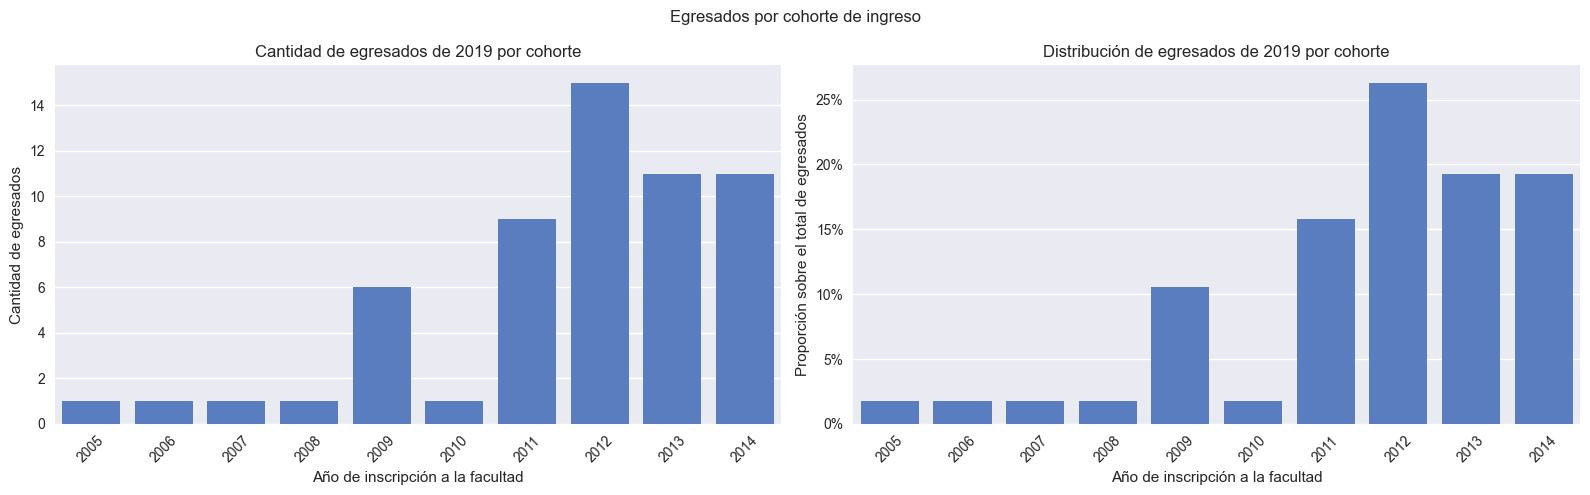

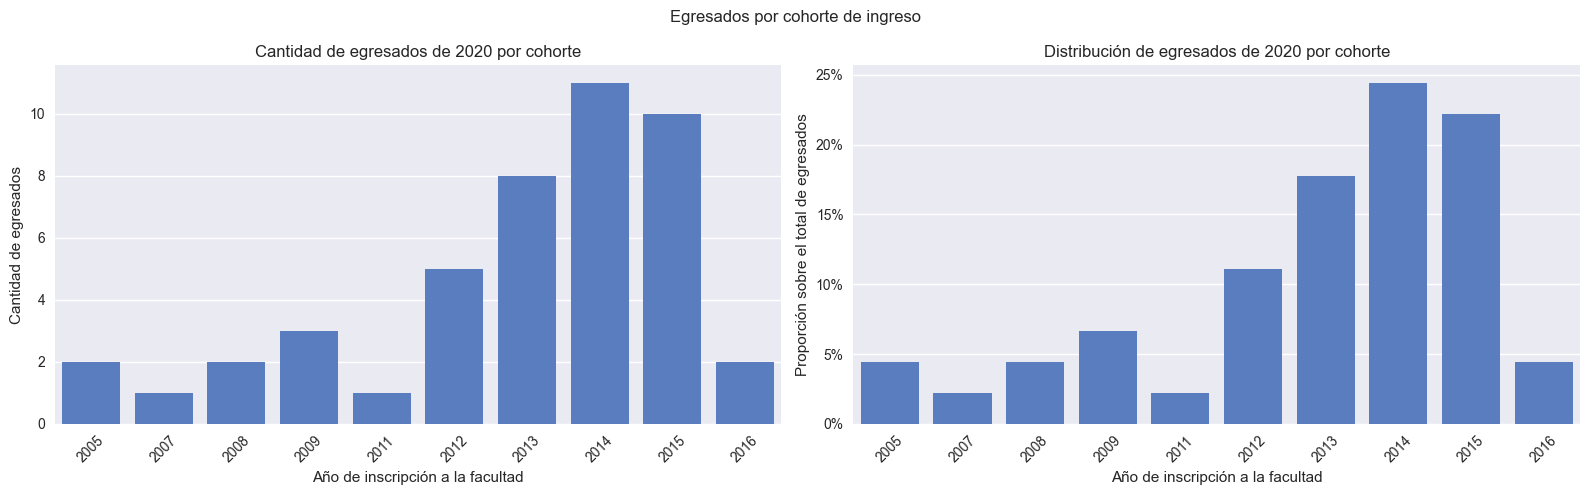

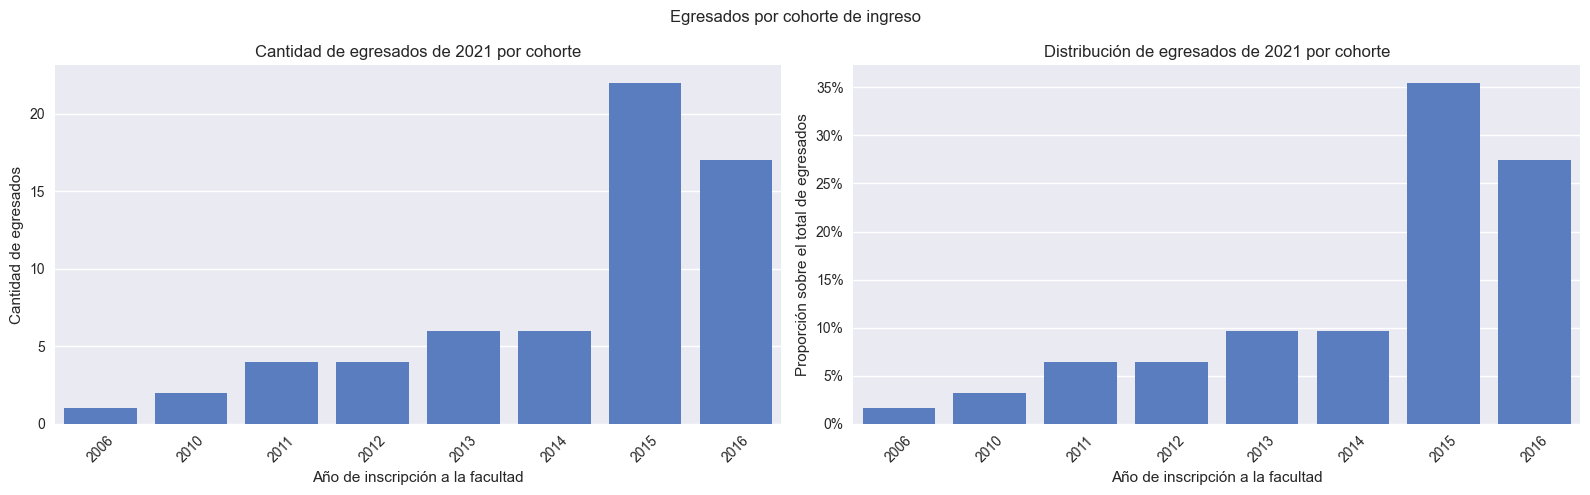

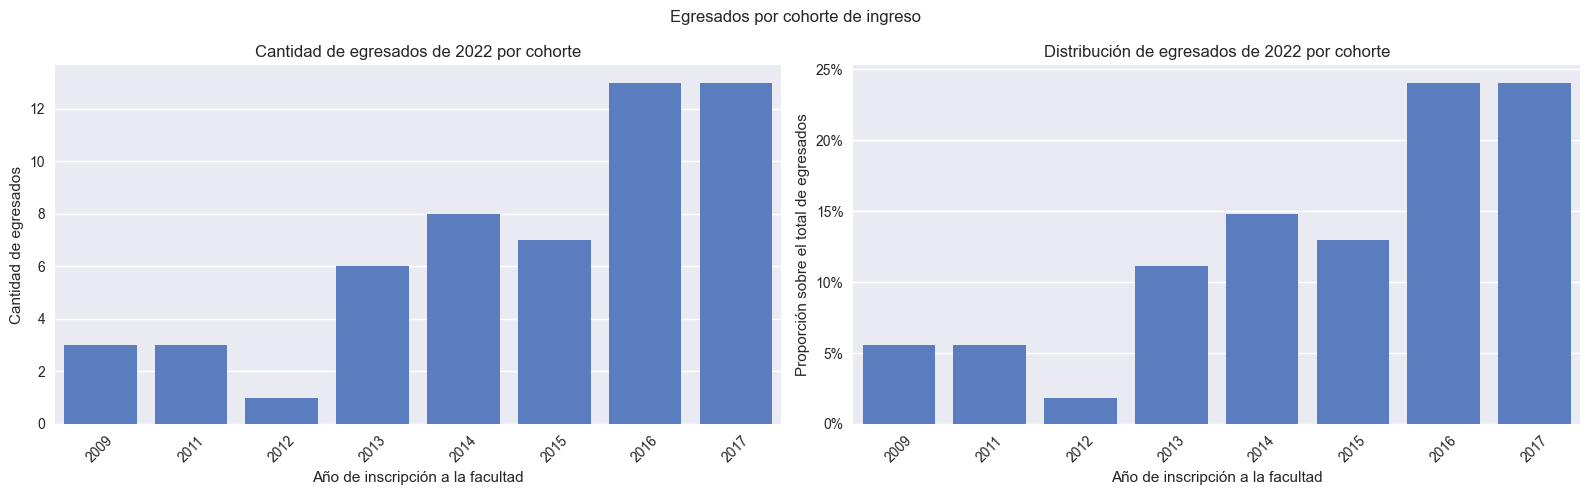

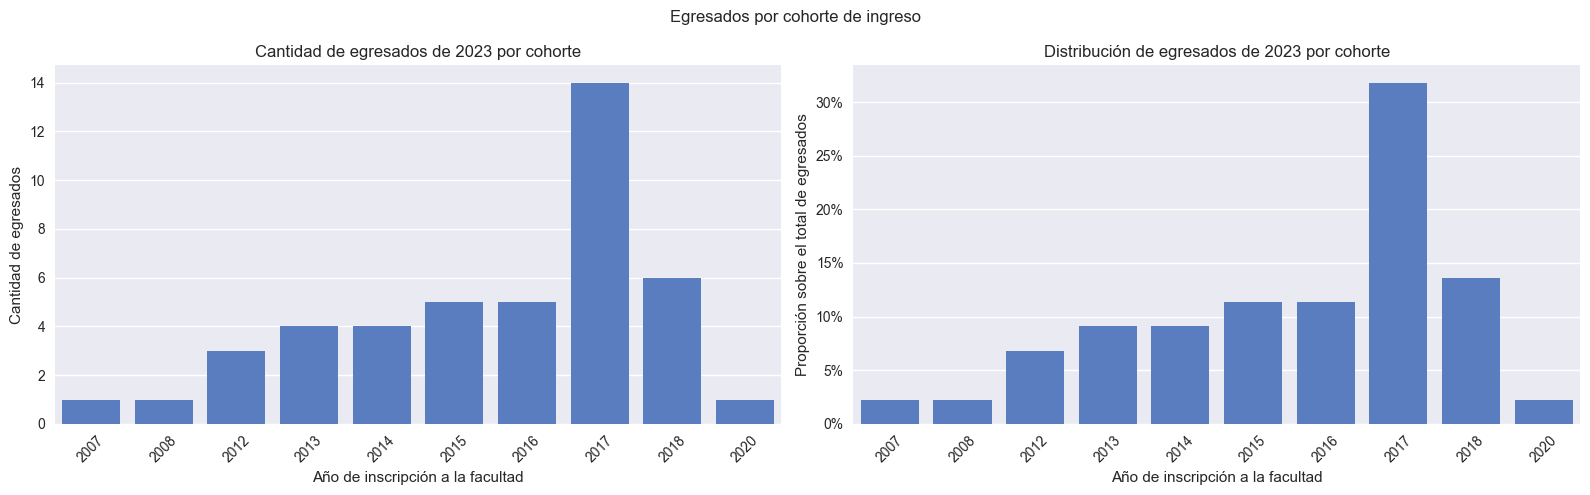

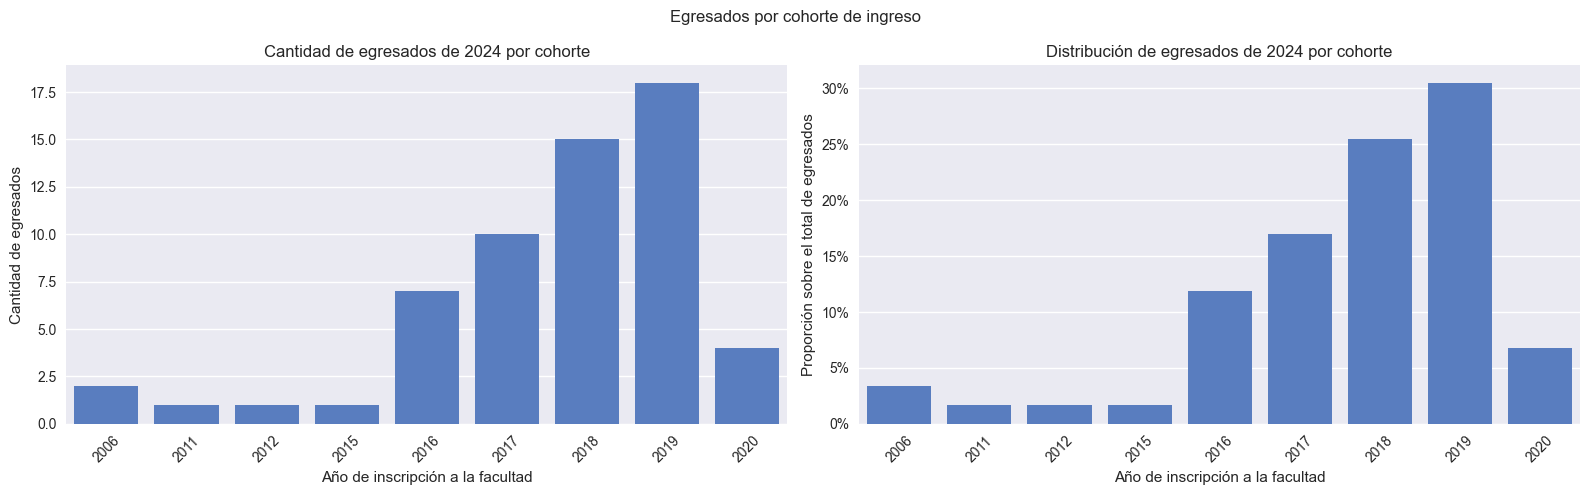

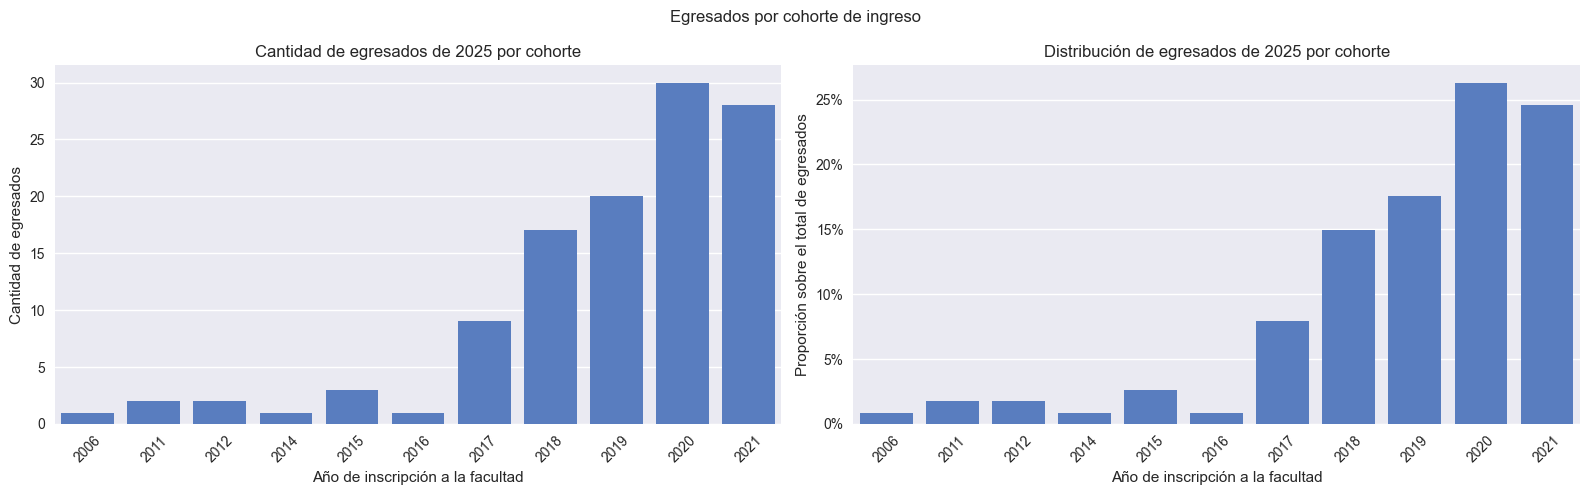

In [32]:
plot_egresados_fisica_por_anio(egresados_fisica)

In [33]:
egresados_fisica['tiempo_cursando'] = egresados_fisica['anio_egreso'] - egresados_fisica['año_inscripcion_facultad'] + 1

egresados_fisica_filtrado = egresados_fisica[(egresados_fisica['anio_egreso'] >= 2014) & (egresados_fisica['anio_egreso'] <= 2019)]

tabla_tiempo_cursando = (
    egresados_fisica_filtrado.groupby('tiempo_cursando')['dni']
    .count()
    .reset_index()
    .rename(columns={'dni': 'total_egreso'})
    .sort_values('tiempo_cursando')
    .reset_index(drop=True)
)

tabla_tiempo_cursando

,tiempo_cursando,total_egreso
0,3,1
1,5,6
2,6,71
3,7,71
4,8,55
5,9,31
6,10,10
7,11,15
8,12,3
9,13,6


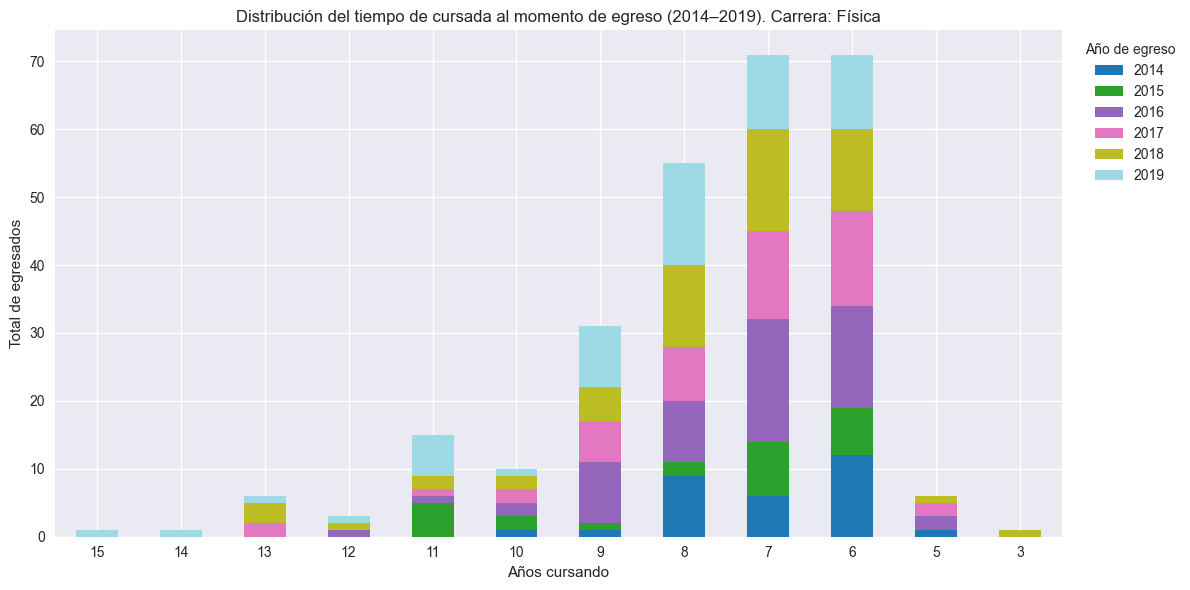

In [34]:
pivot = (
    egresados_fisica_filtrado.groupby(['tiempo_cursando', 'anio_egreso'])['dni']
    .count()
    .unstack(fill_value=0)
)

# orden descendente en el eje x
pivot = pivot.loc[sorted(pivot.index, reverse=True)]

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_xlabel('Años cursando')
ax.set_ylabel('Total de egresados')
ax.set_title('Distribución del tiempo de cursada al momento de egreso (2014–2019). Carrera: Física')
ax.legend(title='Año de egreso', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()